In [91]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import seaborn as sns
import plotnine as p9
import numpy as np
import matplotlib.pyplot as plt


In [2]:
%pip install composable

In [131]:
import composable.records as rec

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder

# Model selection stuff
from sklearn.model_selection import train_test_split,KFold, StratifiedKFold, cross_validate, GridSearchCV


#Numeric Classic Classifiers
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder,SplineTransformer,PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor


# Class Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay,confusion_matrix

from sklearn.compose import make_column_transformer,ColumnTransformer,TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline


from sklearn.impute import SimpleImputer


# Classic regressors
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

# Metrics to use on the test set
# metric(y_test, y_predict)
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# ** Part 1: Housing Price prediction (numeric prediction)**



#### We will be using Linear, Lasso, Ridge, kNN, and new regressors like decision tree, random forest, gradient distribution, ADA boost and histogram gradient to predict the housing price for ames homes

In [5]:
(ames :=

pl.read_csv('./sample_data/AmesHousing.csv')


)

Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,…,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
i64,i64,i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64
1,526301100,20,"""RL""",141,31770,"""Pave""","""NA""","""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",6,5,1960,1960,"""Hip""","""CompShg""","""BrkFace""","""Plywood""","""Stone""",112,"""TA""","""TA""","""CBlock""","""TA""","""Gd""","""Gd""","""BLQ""",639,"""Unf""",…,0,0,1656,1,0,1,0,3,1,"""TA""",7,"""Typ""",2,"""Gd""","""Attchd""",1960,"""Fin""",2,528,"""TA""","""TA""","""P""",210,62,0,0,0,0,"""NA""","""NA""","""NA""",0,5,2010,"""WD ""","""Normal""",215000
2,526350040,20,"""RH""",80,11622,"""Pave""","""NA""","""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""NAmes""","""Feedr""","""Norm""","""1Fam""","""1Story""",5,6,1961,1961,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""None""",0,"""TA""","""TA""","""CBlock""","""TA""","""TA""","""No""","""Rec""",468,"""LwQ""",…,0,0,896,0,0,1,0,2,1,"""TA""",5,"""Typ""",0,"""NA""","""Attchd""",1961,"""Unf""",1,730,"""TA""","""TA""","""Y""",140,0,0,0,120,0,"""NA""","""MnPrv""","""NA""",0,6,2010,"""WD ""","""Normal""",105000
3,526351010,20,"""RL""",81,14267,"""Pave""","""NA""","""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",6,6,1958,1958,"""Hip""","""CompShg""","""Wd Sdng""","""Wd Sdng""","""BrkFace""",108,"""TA""","""TA""","""CBlock""","""TA""","""TA""","""No""","""ALQ""",923,"""Unf""",…,0,0,1329,0,0,1,1,3,1,"""Gd""",6,"""Typ""",0,"""NA""","""Attchd""",1958,"""Unf""",1,312,"""TA""","""TA""","""Y""",393,36,0,0,0,0,"""NA""","""NA""","""Gar2""",12500,6,2010,"""WD ""","""Normal""",172000
4,526353030,20,"""RL""",93,11160,"""Pave""","""NA""","""Reg""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",7,5,1968,1968,"""Hip""","""CompShg""","""BrkFace""","""BrkFace""","""None""",0,"""Gd""","""TA""","""CBlock""","""TA""","""TA""","""No""","""ALQ""",1065,"""Unf""",…,0,0,2110,1,0,2,1,3,1,"""Ex""",8,"""Typ""",2,"""TA""","""Attchd""",1968,"""Fin""",2,522,"""TA""","""TA""","""Y""",0,0,0,0,0,0,"""NA""","""NA""","""NA""",0,4,2010,"""WD ""","""Normal""",244000
5,527105010,60,"""RL""",74,13830,"""Pave""","""NA""","""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""Gilbert""","""Norm""","""Norm""","""1Fam""","""2Story""",5,5,1997,1998,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""None""",0,"""TA""","""TA""","""PConc""","""Gd""","""TA""","""No""","""GLQ""",791,"""Unf""",…,701,0,1629,0,0,2,1,3,1,"""TA""",6,"""Typ""",1,"""TA""","""Attchd""",1997,"""Fin""",2,482,"""TA""","""TA""","""Y""",212,34,0,0,0,0,"""NA""","""MnPrv""","""NA""",0,3,2010,"""WD ""","""Normal""",189900
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2926,923275080,80,"""RL""",37,7937,"""Pave"""

In [109]:
(X_pred :=

 ames
 .drop('SalePrice')
 .to_pandas()
 )

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,1,526301100,20,RL,141.0,31770,Pave,NA,IR1,Lvl,...,0,0,NA,NA,NA,0,5,2010,WD,Normal
1,2,526350040,20,RH,80.0,11622,Pave,NA,Reg,Lvl,...,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal
2,3,526351010,20,RL,81.0,14267,Pave,NA,IR1,Lvl,...,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal
3,4,526353030,20,RL,93.0,11160,Pave,NA,Reg,Lvl,...,0,0,NA,NA,NA,0,4,2010,WD,Normal
4,5,527105010,60,RL,74.0,13830,Pave,NA,IR1,Lvl,...,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NA,IR1,Lvl,...,0,0,NA,GdPrv,NA,0,3,2006,WD,Normal
2926,2927,923276100,20,RL,NaN,8885,Pave,NA,IR1,Low,...,0,0,NA,MnPrv,NA,0,6,2006,WD,Normal
2927,2928,923400125,85,RL,62.0,10441,Pave,NA,Reg,Lvl,...,0,0,NA,MnPrv,Shed,700,7,2006,WD,Normal
2928,2929,924100070,20,RL,77.0,10010,Pave,NA,Reg,Lvl,...,0,0,NA,NA,NA,0,4,2006,WD,Normal


In [110]:
(y_pred :=
 ames
 .select('SalePrice')
 .to_pandas()
)

,SalePrice
0,215000
1,105000
2,172000
3,244000
4,189900
...,...
2925,142500
2926,131000
2927,132000
2928,170000


In [111]:
(cat_columns :=
 ames
 .select(cs.string())
 .columns

)


['MS Zoning',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 'Kitchen Qual',
 'Functional',
 'Fireplace Qu',
 'Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Paved Drive',
 'Pool QC',
 'Fence',
 'Misc Feature',
 'Sale Type',
 'Sale Condition']

In [112]:
X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(
    X_pred,
    y_pred,
   test_size=0.2,
    random_state=42

)

In [113]:
(num_columns :=
   ames
 .select(cs.numeric())
 .drop('SalePrice')
 .columns

 )

['Order',
 'PID',
 'MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold']

In [114]:
(numeric := ames
 .select(cs.numeric())
 ).head(5)

(features_stacked:=
  numeric
  .unpivot(on = cs.numeric() - cs.by_name('SalePrice'),
           index = 'SalePrice',
           variable_name = 'feature',
           value_name = 'value'
           )
)



SalePrice,feature,value
i64,str,i64
215000,"""Order""",1
105000,"""Order""",2
172000,"""Order""",3
244000,"""Order""",4
189900,"""Order""",5
…,…,…
142500,"""Yr Sold""",2006
131000,"""Yr Sold""",2006
132000,"""Yr Sold""",2006


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide


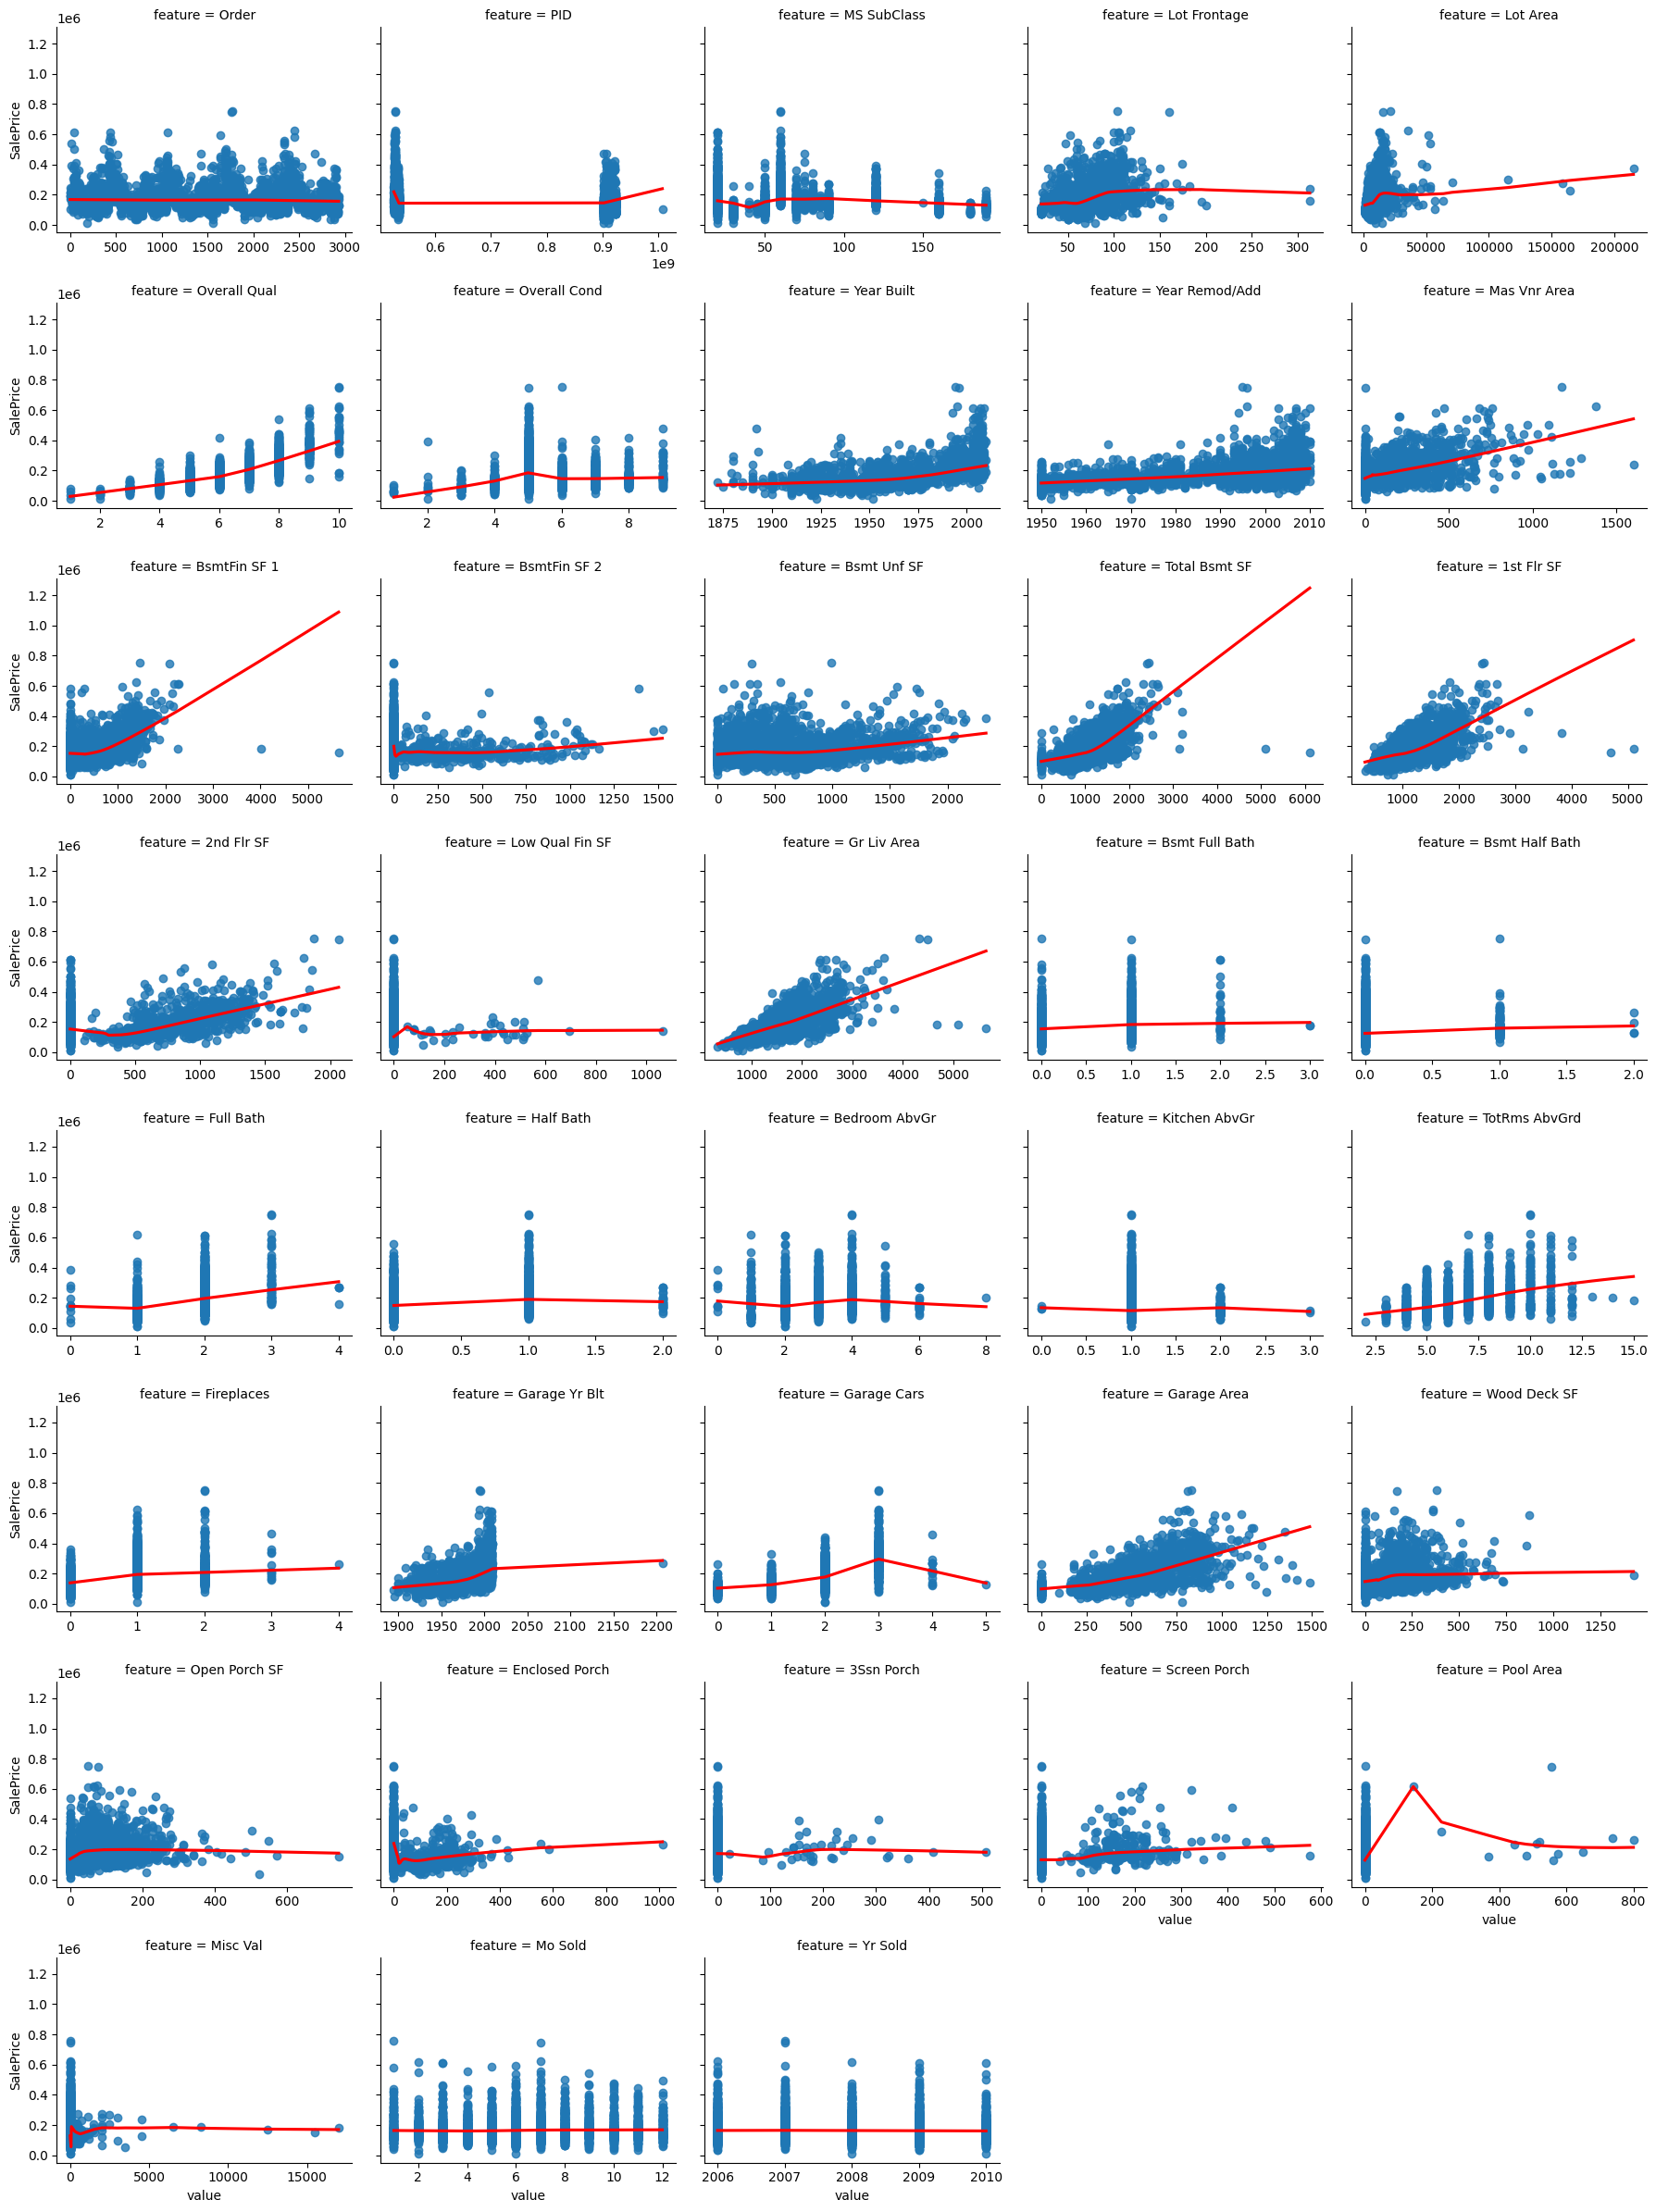

In [79]:
sns.lmplot(features_stacked,
           x = 'value' ,
           y = 'SalePrice',
           col = 'feature',
           col_wrap= 5,
           lowess = True,
           facet_kws  = {'sharex':False},
           line_kws = {'color':'red'},
           height=3,
           aspect=1.2

           )

In [115]:
(cat_pipe := make_pipeline(
        SimpleImputer(strategy='most_frequent'), # Fills in the blanks first
         OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [116]:
(lin_pipe :=  make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler()
)

)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [117]:
(poly_pipe := make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    StandardScaler(),
    PolynomialFeatures()


)

)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('standardscaler', StandardScaler()),
                ('polynomialfeatures', PolynomialFeatures())])

In [118]:
(interactions :=
  Pipeline(steps=[
      ('non_linear', PolynomialFeatures(degree =2, interaction_only =True ))
  ])
 )

Pipeline(steps=[('non_linear', PolynomialFeatures(interaction_only=True))])

In [119]:
(processor_lr := make_pipeline(
 make_column_transformer(
     (cat_pipe, cat_columns),
     (lin_pipe, num_columns)
 )
)
)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MS Zoning', 'Street',
                                                   'Alley', 'Lot Shape',
                                                   'Land Contour', 'Utilities',
                                                   'Lot Config', 'Land Slope',
                                                   'Neighborhood',
                                                   'Conditio...
                                                   'Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Liv Area',
                                                   'Bsmt Full Bath',
                                                   'Bsmt Half Bath',
                                                   'Full Bath', 'Half Bath',
                                                   'Bedroom AbvGr',
                                                   'Kitchen AbvGr',
                                                   'TotRms AbvGrd',
                                                   'Fireplaces',
                                                   'Garage Yr Blt',
                                                   'Garage Cars', 'Garage Area',
                                                   'Wood Deck SF', ...])]))])

In [120]:
(processor_shrink := make_pipeline(

make_column_transformer(
     (cat_pipe, cat_columns), (lin_pipe,num_columns)


)



)
)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MS Zoning', 'Street',
                                                   'Alley', 'Lot Shape',
                                                   'Land Contour', 'Utilities',
                                                   'Lot Config', 'Land Slope',
                                                   'Neighborhood',
                                                   'Conditio...
                                                   'Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Liv Area',
                                                   'Bsmt Full Bath',
                                                   'Bsmt Half Bath',
                                                   'Full Bath', 'Half Bath',
                                                   'Bedroom AbvGr',
                                                   'Kitchen AbvGr',
                                                   'TotRms AbvGrd',
                                                   'Fireplaces',
                                                   'Garage Yr Blt',
                                                   'Garage Cars', 'Garage Area',
                                                   'Wood Deck SF', ...])]))])

In [121]:
(model_ridge :=
 make_pipeline(
    processor_shrink,
     Ridge(alpha=1)

 )
)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehotencoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['MS Zoning',
                                                                    'Street',
                                                                    'Alley',
                                                                    'Lot Shape',
                                                                    'Land '
                                                                    'Contour',
                                                                    'Utilities',
                                                                    'Lot '
                                                                    'Config',
                                                                    'Lan...
                                                                    'Mas Vnr '
                                                                    'Area',
                                                                    'BsmtFin '
                                                                    'SF 1',
                                                                    'BsmtFin '
                                                                    'SF 2',
                                                                    'Bsmt Unf '
                                                                    'SF',
                                                                    'Total '
                                                                    'Bsmt SF',
                                                                    '1st Flr '
                                                                    'SF',
                                                                    '2nd Flr '
                                                                    'SF',
                                                                    'Low Qual '
                                                                    'Fin SF',
                                                                    'Gr Liv '
                                                                    'Area',
                                                                    'Bsmt Full '
                                                                    'Bath',
                                                                    'Bsmt Half '
                                                                    'Bath',
                                                                    'Full Bath',
                                                                    'Half Bath',
                                                                    'Bedroom '
                                                                    'AbvGr',
                                                                    'Kitchen '
                                                                    'AbvGr',
                                                                    'TotRms '
                                                                    'AbvGrd',
                                                                    'Fireplaces',
                                                            

In [122]:
(model_lasso :=
make_pipeline(
    processor_shrink,
    Lasso(alpha = 1)
)
)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehotencoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['MS Zoning',
                                                                    'Street',
                                                                    'Alley',
                                                                    'Lot Shape',
                                                                    'Land '
                                                                    'Contour',
                                                                    'Utilities',
                                                                    'Lot '
                                                                    'Config',
                                                                    'Lan...
                                                                    'Mas Vnr '
                                                                    'Area',
                                                                    'BsmtFin '
                                                                    'SF 1',
                                                                    'BsmtFin '
                                                                    'SF 2',
                                                                    'Bsmt Unf '
                                                                    'SF',
                                                                    'Total '
                                                                    'Bsmt SF',
                                                                    '1st Flr '
                                                                    'SF',
                                                                    '2nd Flr '
                                                                    'SF',
                                                                    'Low Qual '
                                                                    'Fin SF',
                                                                    'Gr Liv '
                                                                    'Area',
                                                                    'Bsmt Full '
                                                                    'Bath',
                                                                    'Bsmt Half '
                                                                    'Bath',
                                                                    'Full Bath',
                                                                    'Half Bath',
                                                                    'Bedroom '
                                                                    'AbvGr',
                                                                    'Kitchen '
                                                                    'AbvGr',
                                                                    'TotRms '
                                                                    'AbvGrd',
                                                                    'Fireplaces',
                                                            

In [123]:
(preprocessor_tree  :=
 make_pipeline(
     make_column_transformer(
        (cat_pipe, cat_columns),
        (lin_pipe, num_columns),
        remainder = "passthrough"
     )
)
)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MS Zoning', 'Street',
                                                   'Alley', 'Lot Shape',
                                                   'Land Contour', 'Utilities',
                                                   'Lot Config', 'Land Slope',...
                                                   'Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Liv Area',
                                                   'Bsmt Full Bath',
                                                   'Bsmt Half Bath',
                                                   'Full Bath', 'Half Bath',
                                                   'Bedroom AbvGr',
                                                   'Kitchen AbvGr',
                                                   'TotRms AbvGrd',
                                                   'Fireplaces',
                                                   'Garage Yr Blt',
                                                   'Garage Cars', 'Garage Area',
                                                   'Wood Deck SF', ...])]))])

In [124]:
(generic_model :=
 Pipeline(steps =
          [
              ('preprocess',None),
              ('regressor', None)

          ]

          )
 )

Pipeline(steps=[('preprocess', None), ('regressor', None)])

In [125]:
( linear_model :=
 make_pipeline( processor_lr,
                 LinearRegression()
)
)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehotencoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['MS Zoning',
                                                                    'Street',
                                                                    'Alley',
                                                                    'Lot Shape',
                                                                    'Land '
                                                                    'Contour',
                                                                    'Utilities',
                                                                    'Lot '
                                                                    'Config',
                                                                    'Lan...
                                                                    'BsmtFin '
                                                                    'SF 1',
                                                                    'BsmtFin '
                                                                    'SF 2',
                                                                    'Bsmt Unf '
                                                                    'SF',
                                                                    'Total '
                                                                    'Bsmt SF',
                                                                    '1st Flr '
                                                                    'SF',
                                                                    '2nd Flr '
                                                                    'SF',
                                                                    'Low Qual '
                                                                    'Fin SF',
                                                                    'Gr Liv '
                                                                    'Area',
                                                                    'Bsmt Full '
                                                                    'Bath',
                                                                    'Bsmt Half '
                                                                    'Bath',
                                                                    'Full Bath',
                                                                    'Half Bath',
                                                                    'Bedroom '
                                                                    'AbvGr',
                                                                    'Kitchen '
                                                                    'AbvGr',
                                                                    'TotRms '
                                                                    'AbvGrd',
                                                                    'Fireplaces',
                                                                    'Garage Yr '
                                                                    'Blt',
                                                           

In [126]:
(knn_model := make_pipeline( processor_lr,
                            KNeighborsRegressor()

)
)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehotencoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['MS Zoning',
                                                                    'Street',
                                                                    'Alley',
                                                                    'Lot Shape',
                                                                    'Land '
                                                                    'Contour',
                                                                    'Utilities',
                                                                    'Lot '
                                                                    'Config',
                                                                    'Lan...
                                                                    'BsmtFin '
                                                                    'SF 1',
                                                                    'BsmtFin '
                                                                    'SF 2',
                                                                    'Bsmt Unf '
                                                                    'SF',
                                                                    'Total '
                                                                    'Bsmt SF',
                                                                    '1st Flr '
                                                                    'SF',
                                                                    '2nd Flr '
                                                                    'SF',
                                                                    'Low Qual '
                                                                    'Fin SF',
                                                                    'Gr Liv '
                                                                    'Area',
                                                                    'Bsmt Full '
                                                                    'Bath',
                                                                    'Bsmt Half '
                                                                    'Bath',
                                                                    'Full Bath',
                                                                    'Half Bath',
                                                                    'Bedroom '
                                                                    'AbvGr',
                                                                    'Kitchen '
                                                                    'AbvGr',
                                                                    'TotRms '
                                                                    'AbvGrd',
                                                                    'Fireplaces',
                                                                    'Garage Yr '
                                                                    'Blt',
                                                           

In [127]:
(model_tree :=
    make_pipeline(
        preprocessor_tree,
        DecisionTreeRegressor()

    )


)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehotencoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['MS Zoning',
                                                                    'Street',
                                                                    'Alley',
                                                                    'Lot Shape',
                                                                    'Land '
                                                                    'Contour',
                                                                    'Utili...
                                                                    'SF 1',
                                                                    'BsmtFin '
                                                                    'SF 2',
                                                                    'Bsmt Unf '
                                                                    'SF',
                                                                    'Total '
                                                                    'Bsmt SF',
                                                                    '1st Flr '
                                                                    'SF',
                                                                    '2nd Flr '
                                                                    'SF',
                                                                    'Low Qual '
                                                                    'Fin SF',
                                                                    'Gr Liv '
                                                                    'Area',
                                                                    'Bsmt Full '
                                                                    'Bath',
                                                                    'Bsmt Half '
                                                                    'Bath',
                                                                    'Full Bath',
                                                                    'Half Bath',
                                                                    'Bedroom '
                                                                    'AbvGr',
                                                                    'Kitchen '
                                                                    'AbvGr',
                                                                    'TotRms '
                                                                    'AbvGrd',
                                                                    'Fireplaces',
                                                                    'Garage Yr '
                                                                    'Blt',
                                                                    'Garage '
                                                                    'Cars',
                                                                    'Garage '
                                                             

In [128]:
(model_forest :=
    make_pipeline(
        preprocessor_tree,
        RandomForestRegressor()
    )


 )

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehotencoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['MS Zoning',
                                                                    'Street',
                                                                    'Alley',
                                                                    'Lot Shape',
                                                                    'Land '
                                                                    'Contour',
                                                                    'Utili...
                                                                    'SF 1',
                                                                    'BsmtFin '
                                                                    'SF 2',
                                                                    'Bsmt Unf '
                                                                    'SF',
                                                                    'Total '
                                                                    'Bsmt SF',
                                                                    '1st Flr '
                                                                    'SF',
                                                                    '2nd Flr '
                                                                    'SF',
                                                                    'Low Qual '
                                                                    'Fin SF',
                                                                    'Gr Liv '
                                                                    'Area',
                                                                    'Bsmt Full '
                                                                    'Bath',
                                                                    'Bsmt Half '
                                                                    'Bath',
                                                                    'Full Bath',
                                                                    'Half Bath',
                                                                    'Bedroom '
                                                                    'AbvGr',
                                                                    'Kitchen '
                                                                    'AbvGr',
                                                                    'TotRms '
                                                                    'AbvGrd',
                                                                    'Fireplaces',
                                                                    'Garage Yr '
                                                                    'Blt',
                                                                    'Garage '
                                                                    'Cars',
                                                                    'Garage '
                                                             

In [129]:
(folds := KFold(n_splits = 3, shuffle = True, random_state = 1490)

)


KFold(n_splits=3, random_state=1490, shuffle=True)

In [ ]:
(XGBoost_reg_grid := {
    'preprocess': [preprocessor_tree],
    'regressor': [XGBRegressor()],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 4, 5],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0]
})

In [132]:
(linear_grid := {
    'preprocess': [processor_lr],
    'regressor': [LinearRegression()]
}
)


(grid_knn := {
    'preprocess': [processor_lr],       # Was 'pre' or 'columntransformer'
    'regressor': [KNeighborsRegressor()], # Was 'model' or 'learn_regressor'
    'regressor__n_neighbors': [3, 5, 7, 11],
    'regressor__weights': ['uniform', 'distance']
}
)



(grid_lasso := {
    'preprocess': [processor_shrink],
    'regressor': [Lasso()],
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]
}
)



(grid_ridge := {
    'preprocess': [processor_shrink], # Using your shrinkage preprocessor
    'regressor': [Ridge()],
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'regressor__max_iter': [5000]
}
)

(grid_tree := {
    'preprocess': [preprocessor_tree],          # Swap in the tree processor
    'regressor': [DecisionTreeRegressor()],  # Use Regressor for numeric values!
    'regressor__max_depth': [3, 5, 10]
}
)


(grid_forest := {
    'preprocess': [preprocessor_tree],
    'regressor': [RandomForestRegressor()],
    'regressor__max_depth': [2, 3, 4, 5],
    'regressor__n_estimators': [10, 100, 500]
}
)
(GB_grid := {
    'preprocess': [preprocessor_tree],
    'regressor': [GradientBoostingRegressor()],
    'regressor__n_estimators': [50, 100, 200],
    'regressor__learning_rate': [0.01, 0.1, 0.5],
    'regressor__max_depth': [3, 5, 7]
}
)

(ada_grid := {
    'preprocess': [preprocessor_tree],
    'regressor': [AdaBoostRegressor()],
    'regressor__n_estimators': [50, 100, 200],
    'regressor__learning_rate': [0.01, 0.1, 0.5],
    'regressor__loss': ['linear', 'square', 'exponential']
})

(hist_GB_grid := {
    'preprocess': [preprocessor_tree],
    'regressor': [HistGradientBoostingRegressor()],
    'regressor__learning_rate': [0.1, 0.5, 1.0],
    'regressor__max_iter': [25, 50, 100],
    'regressor__max_depth': [3, 4, 5],
    'regressor__max_bins': [2, 77, 152, 227]
})


(XGBoost_reg_grid := {
    'preprocess': [preprocessor_tree],
    'regressor': [XGBRegressor()],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 4, 5],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0]
})

{'preprocess': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('pipeline-1',
                                                    Pipeline(steps=[('simpleimputer',
                                                                     SimpleImputer(strategy='most_frequent')),
                                                                    ('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore',
                                                                                   sparse_output=False))]),
                                                    ['MS Zoning', 'Street',
                                                     'Alley', 'Lot Shape',
                                                     'Land Contour', 'Utilities',
                                                     'Lot Config', 'Land Slope',...
  

In [133]:
(combined_grid :=

[ linear_grid, grid_knn, grid_lasso,  grid_ridge ,  grid_tree, grid_forest, GB_grid, ada_grid, hist_GB_grid, XGBoost_reg_grid ]
)

[{'preprocess': [Pipeline(steps=[('columntransformer',
                    ColumnTransformer(transformers=[('pipeline-1',
                                                     Pipeline(steps=[('simpleimputer',
                                                                      SimpleImputer(strategy='most_frequent')),
                                                                     ('onehotencoder',
                                                                      OneHotEncoder(handle_unknown='ignore',
                                                                                    sparse_output=False))]),
                                                     ['MS Zoning', 'Street',
                                                      'Alley', 'Lot Shape',
                                                      'Land Contour', 'Utilities',
                                                      'Lot Config', 'Land Slope',
                                                      'N

In [134]:
(combined_grid :=

[ linear_grid, grid_knn, grid_lasso,  grid_ridge ,  grid_tree, grid_forest, GB_grid, ada_grid, hist_GB_grid, XGBoost_reg_grid ]
)

[{'preprocess': [Pipeline(steps=[('columntransformer',
                    ColumnTransformer(transformers=[('pipeline-1',
                                                     Pipeline(steps=[('simpleimputer',
                                                                      SimpleImputer(strategy='most_frequent')),
                                                                     ('onehotencoder',
                                                                      OneHotEncoder(handle_unknown='ignore',
                                                                                    sparse_output=False))]),
                                                     ['MS Zoning', 'Street',
                                                      'Alley', 'Lot Shape',
                                                      'Land Contour', 'Utilities',
                                                      'Lot Config', 'Land Slope',
                                                      'N

In [135]:
(generic_model :=
 Pipeline(steps =
          [
              ('preprocess',None),
              ('regressor', None)

          ]

          )
 )

Pipeline(steps=[('preprocess', None), ('regressor', None)])

In [136]:
(combined_gridsearch := GridSearchCV(generic_model,combined_grid, cv = folds, scoring = 'neg_mean_squared_error',n_jobs = -1,
    verbose = 1, error_score = 'raise')
)

GridSearchCV(cv=KFold(n_splits=3, random_state=1490, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocess', None),
                                       ('regressor', None)]),
             n_jobs=-1,
             param_grid=[{'preprocess': [Pipeline(steps=[('columntransformer',
                                                          ColumnTransformer(transformers=[('pipeline-1',
                                                                                           Pipeline(steps=[('simpleimputer',
                                                                                                            SimpleImputer(strategy='most_frequent')),
                                                                                                           ('on...
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...)],
                          'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
                          'regressor__max_depth': [3, 4, 5],
                          'regressor__n_estimators': [100, 200, 300],
                          'regressor__subsample': [0.7, 0.8, 0.9, 1.0]}],
             scoring='neg_mean_squared_error', verbose=1)

In [137]:
combined_gridsearch.fit(X_train_housing, y_train_housing)

Fitting 3 folds for each of 341 candidates, totalling 1023 fits


GridSearchCV(cv=KFold(n_splits=3, random_state=1490, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocess', None),
                                       ('regressor', None)]),
             n_jobs=-1,
             param_grid=[{'preprocess': [Pipeline(steps=[('columntransformer',
                                                          ColumnTransformer(transformers=[('pipeline-1',
                                                                                           Pipeline(steps=[('simpleimputer',
                                                                                                            SimpleImputer(strategy='most_frequent')),
                                                                                                           ('on...
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...)],
                          'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
                          'regressor__max_depth': [3, 4, 5],
                          'regressor__n_estimators': [100, 200, 300],
                          'regressor__subsample': [0.7, 0.8, 0.9, 1.0]}],
             scoring='neg_mean_squared_error', verbose=1)

In [138]:
combined_gridsearch.best_params_,combined_gridsearch.best_score_

({'preprocess': Pipeline(steps=[('columntransformer',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('pipeline-1',
                                                    Pipeline(steps=[('simpleimputer',
                                                                     SimpleImputer(strategy='most_frequent')),
                                                                    ('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore',
                                                                                   sparse_output=False))]),
                                                    ['MS Zoning', 'Street',
                                                     'Alley', 'Lot Shape',
                                                     'Land Contour', 'Utilities',
                                                     'Lot Config', 'Land Slope',...
  

The best regressor is the **XGBoost Regressor** for predicting the housing price for the ames housing dataset with parameters regressor__learning_rate: 0.1,
regressor__max_depth : 3,
regressor__n_estimators : 300.                                                                        With a best score of -551915925.3
wherein taken a sqaure root of this value will give a RMSE of $23492.3 (average standard error)

In [32]:
rec.map(np.mean)

<function map at 0x7aa006370c20>

In [139]:
my_score = ['neg_mean_squared_error']

(scores :=
 cross_validate(combined_gridsearch, X_train_housing, y_train_housing,
                cv = folds,
                scoring = my_score,
                n_jobs = -1)
  >> rec.subset([f'test_{m}' for m in my_score])
  >> rec.map(np.mean)


)

{'test_neg_mean_squared_error': np.float64(-563180906.6666666)}

Using a cross-validate the resulting score for test negative mean square error is -551915925.3 (wherein we take the square root of the absolute value ) to get $23492.9

In [140]:
best_model = combined_gridsearch.best_estimator_

y_pred_test = best_model.predict(X_test_housing)

In [141]:
from sklearn.metrics import mean_squared_error
import numpy as np

test_mse = mean_squared_error(y_test_housing, y_pred_test)
test_rmse = np.sqrt(test_mse)

print(f"Test Mean Squared Error (MSE): {test_mse}")
print(f"Test Root Mean Squared Error (RMSE): {test_rmse}")

Test Mean Squared Error (MSE): 571051136.0
Test Root Mean Squared Error (RMSE): 23896.67625424088


Test Root Mean Square Error (RMSE) is $26193

# **Part 2: Classifiers**

We will be using a series of previous classic classifiers like  kNN, Naive Bayes,  log reg, LDA,  QDA,  as well as newer ensemble classifiers like decision trees, random forest, ADA boost, Gradient Boost, Histogram Grad Boost, and XGBoost to make predictions on income for a dataset on adults and whether they make over 50k or not

In [34]:

(adult := pl.read_csv('./sample_data/adult.csv') )

age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str
90,"""?""",77053,"""HS-grad""",9,"""Widowed""","""?""","""Not-in-family""","""White""","""Female""",0,4356,40,"""United-States""","""<=50K"""
82,"""Private""",132870,"""HS-grad""",9,"""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",0,4356,18,"""United-States""","""<=50K"""
66,"""?""",186061,"""Some-college""",10,"""Widowed""","""?""","""Unmarried""","""Black""","""Female""",0,4356,40,"""United-States""","""<=50K"""
54,"""Private""",140359,"""7th-8th""",4,"""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""
41,"""Private""",264663,"""Some-college""",10,"""Separated""","""Prof-specialty""","""Own-child""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
22,"""Private""",310152,"""Some-college""",10,"""Never-married""","""Protective-serv""","""Not-in-family""","""White""","""Male""",0,0,40,"""United-States""","""<=50K"""
27,"""Private""",257302,"""Assoc-acdm""",12,"""Married-civ-spouse""","""Tech-support""","""Wife""","""White""","""Female""",0,0,38,"""United-States""","""<=50K"""
40,"""Private""",154374,"""HS-grad""",9,"""Married-civ-spouse""","""Machine-op-inspct""","""Husband""","""White""","""Male""",0,0,40,"""United-States""",""">50K"""


In [35]:
(X_adult_pred :=

  adult
 .drop('income')


)

age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str
90,"""?""",77053,"""HS-grad""",9,"""Widowed""","""?""","""Not-in-family""","""White""","""Female""",0,4356,40,"""United-States"""
82,"""Private""",132870,"""HS-grad""",9,"""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",0,4356,18,"""United-States"""
66,"""?""",186061,"""Some-college""",10,"""Widowed""","""?""","""Unmarried""","""Black""","""Female""",0,4356,40,"""United-States"""
54,"""Private""",140359,"""7th-8th""",4,"""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",0,3900,40,"""United-States"""
41,"""Private""",264663,"""Some-college""",10,"""Separated""","""Prof-specialty""","""Own-child""","""White""","""Female""",0,3900,40,"""United-States"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
22,"""Private""",310152,"""Some-college""",10,"""Never-married""","""Protective-serv""","""Not-in-family""","""White""","""Male""",0,0,40,"""United-States"""
27,"""Private""",257302,"""Assoc-acdm""",12,"""Married-civ-spouse""","""Tech-support""","""Wife""","""White""","""Female""",0,0,38,"""United-States"""
40,"""Private""",154374,"""HS-grad""",9,"""Married-civ-spouse""","""Machine-op-inspct""","""Husband""","""White""","""Male""",0,0,40,"""United-States"""


In [36]:
(folds_adult := StratifiedKFold(n_splits = 3, shuffle = True, random_state = 1490))

StratifiedKFold(n_splits=3, random_state=1490, shuffle=True)

In [37]:
(cat_columns :=
 X_adult_pred.select(cs.string()).columns
)




['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

In [38]:
(num_columns :=
 X_adult_pred.select(cs.numeric()).columns
 )

['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week']

In [39]:
(processor_adult := make_pipeline(
    make_column_transformer(
        (cat_pipe, cat_columns),
        (lin_pipe, num_columns),
        remainder='passthrough'
    )
))

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])]))])

In [40]:
(y_adult_pred :=

  adult
  .select('income')



)

income
str
"""<=50K"""
"""<=50K"""
"""<=50K"""
"""<=50K"""
"""<=50K"""
…
"""<=50K"""
"""<=50K"""
""">50K"""


In [42]:
(uniq_labels :=
 y_adult_pred
 .unique()
 .get_column('income')
 .to_numpy()
)

array(['>50K', '<=50K'], dtype=object)

In [58]:
le = LabelEncoder()
le.fit(uniq_labels)

(y_ind :=
  le.transform(y_adult_pred.get_column('income'))
)

array([0, 0, 0, ..., 1, 0, 0])

In [59]:
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_adult_pred.to_pandas(),
    y_ind,
   test_size=0.2,
    random_state=42
)

In [60]:
(generic_cls :=
 Pipeline(steps = [
     ('preprocess', processor_adult), # Use the comprehensive preprocessor
     ('classifier', None)  # <-- classifier goes here
 ])
)

Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehotencoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['workclass',
                                                                    'education',
                                                                    'marital.status',
                                                                    'occupation',
                                                                    'relationship',
                                                                    'race',
                                                                    'sex',
                                                                    'native.country']),
                                                                  ('pipeline-2',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['age',
                                                                    'fnlwgt',
                                                                    'education.num',
                                                                    'capital.gain',
                                                                    'capital.loss',
                                                                    'hours.per.week'])]))])),
                ('classifier', None)])

In [61]:
(knn_grid:= {'classifier': [KNeighborsClassifier()],
   'classifier__n_neighbors': list(range(2,12,2)),
    'classifier__metric': ['l1','l2'],
    'classifier__weights': ['uniform','distance']

        })

{'classifier': [KNeighborsClassifier()],
 'classifier__n_neighbors': [2, 4, 6, 8, 10],
 'classifier__metric': ['l1', 'l2'],
 'classifier__weights': ['uniform', 'distance']}

In [62]:
(tree_grid :=
 {'classifier' : [DecisionTreeClassifier()],
    'classifier__max_depth': [3, 5, 10, 15, 20],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5, 10]


 }
)

{'classifier': [DecisionTreeClassifier()],
 'classifier__max_depth': [3, 5, 10, 15, 20],
 'classifier__min_samples_leaf': [1, 2, 4],
 'classifier__min_samples_split': [2, 5, 10]}

In [63]:
(nontuning_grid :=


      {'classifier': [LogisticRegression(),
                      GaussianNB(),
                      LinearDiscriminantAnalysis(),
                      QuadraticDiscriminantAnalysis()

      ]

      }



)

{'classifier': [LogisticRegression(),
  GaussianNB(),
  LinearDiscriminantAnalysis(),
  QuadraticDiscriminantAnalysis()]}

In [64]:
(ada_grid :=
 {
      'classifier': [AdaBoostClassifier()],
      'classifier__learning_rate': np.linspace(0.1, 1.0, 10),
      'classifier__n_estimators': [25, 50, 100],
 })

{'classifier': [AdaBoostClassifier()],
 'classifier__learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'classifier__n_estimators': [25, 50, 100]}

In [65]:
(GB_grid :=
 {
 'classifier': [GradientBoostingClassifier()],
 'classifier__learning_rate': np.linspace(0.1, 1.0, 10),
 'classifier__n_estimators': [25, 50, 100],
 'classifier__max_depth': [3, 4, 5],
 })

{'classifier': [GradientBoostingClassifier()],
 'classifier__learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'classifier__n_estimators': [25, 50, 100],
 'classifier__max_depth': [3, 4, 5]}

In [66]:
(hist_GB_grid :=
    {
        'classifier': [HistGradientBoostingClassifier()],
        'classifier__learning_rate': np.linspace(0.1, 1.0, 10),
        'classifier__max_iter': [25, 50, 100],
        'classifier__max_depth': [3, 4, 5],
        'classifier__max_bins': np.arange(2, 255, 75),
    }
)

{'classifier': [HistGradientBoostingClassifier()],
 'classifier__learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'classifier__max_iter': [25, 50, 100],
 'classifier__max_depth': [3, 4, 5],
 'classifier__max_bins': array([  2,  77, 152, 227])}

In [80]:
(XGB_grid :=
    {
        'classifier': [XGBClassifier()],
        'classifier__learning_rate': np.linspace(0.01, 0.2, 5),
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 4, 5],
        'classifier__subsample': np.arange(0.7, 1.0, 0.1),
    }
)

{'classifier': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...)],
 'classifier__learning_rate': array([0.01  , 0.0575, 0.105 , 0.1525, 0.2   ]),
 'classifier__n_estimators': [50, 100, 200],
 'classifier__max_depth': [3, 4, 5],
 'classifier__subsample': array([0.7, 0.

In [81]:
(combined_grid := [knn_grid, tree_grid, nontuning_grid, ada_grid, GB_grid, hist_GB_grid,XGB_grid])




[{'classifier': [KNeighborsClassifier()],
  'classifier__n_neighbors': [2, 4, 6, 8, 10],
  'classifier__metric': ['l1', 'l2'],
  'classifier__weights': ['uniform', 'distance']},
 {'classifier': [DecisionTreeClassifier()],
  'classifier__max_depth': [3, 5, 10, 15, 20],
  'classifier__min_samples_leaf': [1, 2, 4],
  'classifier__min_samples_split': [2, 5, 10]},
 {'classifier': [LogisticRegression(),
   GaussianNB(),
   LinearDiscriminantAnalysis(),
   QuadraticDiscriminantAnalysis()]},
 {'classifier': [AdaBoostClassifier()],
  'classifier__learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
  'classifier__n_estimators': [25, 50, 100]},
 {'classifier': [GradientBoostingClassifier()],
  'classifier__learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
  'classifier__n_estimators': [25, 50, 100],
  'classifier__max_depth': [3, 4, 5]},
 {'classifier': [HistGradientBoostingClassifier()],
  'classifier__learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5

In [82]:
(combined_grid_search := GridSearchCV(generic_cls, combined_grid, cv = folds_adult, scoring = 'accuracy', n_jobs = -1, verbose = 1, error_score = 'raise'))



GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=1490, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocess',
                                        Pipeline(steps=[('columntransformer',
                                                         ColumnTransformer(remainder='passthrough',
                                                                           transformers=[('pipeline-1',
                                                                                          Pipeline(steps=[('simpleimputer',
                                                                                                           SimpleImputer(strategy='most_frequent')),
                                                                                                          ('onehotencoder',
                                                                                                           OneHotEncoder(han...
                                                       min_child_weight=None,
                                                       missing=nan,
                                                       monotone_constraints=None,
                                                       multi_strategy=None,
                                                       n_estimators=None,
                                                       n_jobs=None,
                                                       num_parallel_tree=None, ...)],
                          'classifier__learning_rate': array([0.01  , 0.0575, 0.105 , 0.1525, 0.2   ]),
                          'classifier__max_depth': [3, 4, 5],
                          'classifier__n_estimators': [50, 100, 200],
                          'classifier__subsample': array([0.7, 0.8, 0.9, 1. ])}],
             scoring='accuracy', verbose=1)

In [ ]:
(folds_adult := StratifiedKFold(n_splits = 3, shuffle = True, random_state = 1490))

In [83]:
combined_grid_search.fit(X_train_adult, y_train_adult)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=1490, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocess',
                                        Pipeline(steps=[('columntransformer',
                                                         ColumnTransformer(remainder='passthrough',
                                                                           transformers=[('pipeline-1',
                                                                                          Pipeline(steps=[('simpleimputer',
                                                                                                           SimpleImputer(strategy='most_frequent')),
                                                                                                          ('onehotencoder',
                                                                                                           OneHotEncoder(han...
                                                       min_child_weight=None,
                                                       missing=nan,
                                                       monotone_constraints=None,
                                                       multi_strategy=None,
                                                       n_estimators=None,
                                                       n_jobs=None,
                                                       num_parallel_tree=None, ...)],
                          'classifier__learning_rate': array([0.01  , 0.0575, 0.105 , 0.1525, 0.2   ]),
                          'classifier__max_depth': [3, 4, 5],
                          'classifier__n_estimators': [50, 100, 200],
                          'classifier__subsample': array([0.7, 0.8, 0.9, 1. ])}],
             scoring='accuracy', verbose=1)

XGBoost has been selected as the best classifier to predict the income variable. With the classifier model determined we can start doing some parameters testing and visualization to gauge how well it really does

In [86]:
(XGB_model := combined_grid_search.best_estimator_)

XGB_model.predict(X_test_adult)

array([0, 0, 0, ..., 1, 0, 0])

In [87]:
scores = ['accuracy',
           'balanced_accuracy',
           'f1_micro'
]

(XGB_scores := cross_validate(XGB_model, X_adult_pred, y_ind, cv = folds_adult, scoring = scores,
                              n_jobs = -1)

     >>rec.subset([f'test_{s}' for s in scores])
      >>rec.map(np.mean)
)





{'test_accuracy': np.float64(0.8727926091259155),
 'test_balanced_accuracy': np.float64(0.7967456057263034),
 'test_f1_micro': np.float64(0.8727926091259155)}

Good scores from XGBoost with test_accuracy at 0.873, test balanced accuracy at 0.797, and test f1 micro is 0.873

In [106]:
y_pred_test =XGB_model.predict(X_test_adult)

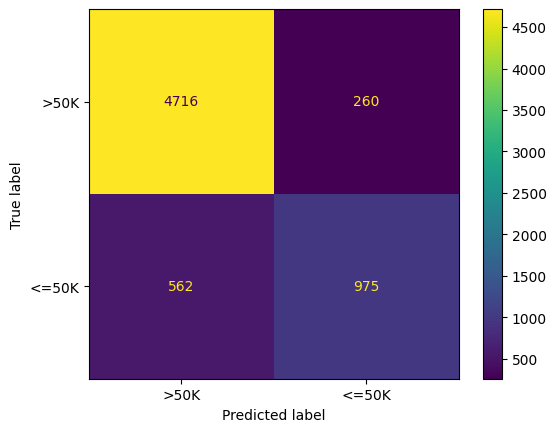

In [97]:
XGB_model.fit(X_train_adult, y_train_adult)


ConfusionMatrixDisplay.from_estimator(XGB_model,X_test_adult, y_test_adult, display_labels = uniq_labels  )

In [107]:
tn, fp, fn, tp = confusion_matrix(y_test_adult, y_pred_test).ravel().tolist()
(tn, fp, fn, tp)
(sensitivity := tp / (tp + fn))
(specificity := tn / (tn + fp))
(precision := tp / (tp + fp))

sensitivity, specificity, precision

(0.6343526350032531, 0.9477491961414791, 0.7894736842105263)

Some relatively good stats for the XGB and confusion plot- it was especially good at determining true negatives (when they actually were greater than 50000) and positive predictions ( proportion that predicted less than 50000  and were correct)

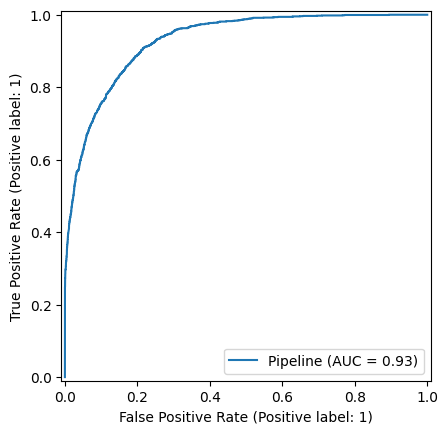

In [108]:
(TGB_disp := RocCurveDisplay.from_estimator(XGB_model, X_test_adult, y_test_adult))

The ROC curve indicates that the TPR over FPR proportion is very consistent with a very steep curve as it moves towards (1,1). The AUC is very high at 0.93 which is a very good indicator that this model distinguish between the 2 classes.